# Variance-Regularised Random Measure Optimal Transport

## Mathematical Background

This notebook implements the **variance-penalised optimal transport** problem from Direction 1 of the paper. We work in the space $L^2_W(\mathbb{R}^d) = L^2(\Omega; (P_2(\mathbb{R}^d), W_2))$ of random probability measures.

Given a fixed random measure $\xi \in L^2_{W,ac}(\mathbb{R}^d)$, we seek:
$$M^* = \underset{M \in L^2_{W,ac}}{\operatorname{argmin}} \; \mathcal{F}_\lambda(M) := \underbrace{\mathbb{E}_\omega[W_2^2(\xi(\omega), M(\omega))]}_{\text{fidelity}} + \lambda \underbrace{\mathbb{E}_\omega[W_2^2(M(\omega), \bar{M})]}_{\text{Uncertainty}}$$

where $\bar{M} = \operatorname{argmin}_{\nu} \mathbb{E}_\omega[W_2^2(M(\omega), \nu)]$ is the **Wasserstein barycenter** of the realisations of $M$.

### The Gradient Flow

The $L^2_W$ Wasserstein gradient flow drives each realisation $M_t(\omega)$ via the PDE:
$$\partial_t M_t(\omega) + \operatorname{div}\left(M_t(\omega) \cdot \left[S_{\omega,t} + \lambda R_{\omega,t} - (1+\lambda)\operatorname{id}\right]\right) = 0$$

where:
- $S_{\omega,t} = T_{M_t(\omega) \to \xi(\omega)}$ is the Brenier map from the current realisation to the **target** $\xi(\omega)$
- $R_{\omega,t} = T_{M_t(\omega) \to \bar{M}_t}$ is the Brenier map from the current realisation to the **barycenter** $\bar{M}_t$

### Implementation via Particle Flow

We represent each realisation $M_t(\omega_i)$ as an empirical measure $\frac{1}{N}\sum_j \delta_{x^i_j(t)}$. The particle update at each step is:
$$x^i_j \leftarrow \frac{S_{\omega_i}(x^i_j) + \lambda R_{\omega_i}(x^i_j)}{1+\lambda}$$

where:
- $S_{\omega_i}(x^i_j)$ is the optimal transport target in $\xi(\omega_i)$ (barycentric projection)
- $R_{\omega_i}(x^i_j)$ is the optimal transport target in the current empirical barycenter $\bar{M}_t$

This is exactly the **fixed-point update** characterising $M^*$, iterated to convergence.

### Limiting Behaviour
- $\lambda = 0$: $M^*(\omega) = \xi(\omega)$ pointwise (no regularisation)
- $\lambda \to \infty$: $M^*(\omega) = \bar{\xi}$ for all $\omega$ (full pooling to the Wasserstein barycenter)
- Intermediate $\lambda$: a convex tradeoff between fidelity and variance reduction

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Ellipse
import matplotlib.cm as cm
from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import cdist
from typing import List, Tuple, Optional, Callable
import warnings
warnings.filterwarnings('ignore')

# BG     = '#F7F4EF'   # warm off-white background
BG     = '#FFFFFF'   # white background

plt.rcParams.update({
    'figure.facecolor': BG,
    'axes.facecolor':   BG,
    'font.family':      'serif',
    'mathtext.fontset': 'cm',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'axes.grid':        False,
})

np.random.seed(13)

plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

print('All packages loaded successfully.')
print('OT will be solved using scipy (linear_sum_assignment for exact discrete OT).')

All packages loaded successfully.
OT will be solved using scipy (linear_sum_assignment for exact discrete OT).


## Core OT Utilities

We implement discrete optimal transport from scratch using the Hungarian algorithm (`scipy.optimize.linear_sum_assignment`), which solves the exact assignment problem for equal-weight empirical measures.

For two empirical measures $\mu = \frac{1}{N}\sum_j \delta_{x_j}$ and $\nu = \frac{1}{N}\sum_j \delta_{y_j}$, the **barycentric projection** of $x_j$ onto $\nu$ under the optimal coupling is:
$$\hat{s}_j = y_{\sigma(j)}$$
where $\sigma$ is the optimal assignment. This approximates the Brenier map $T_{\mu \to \nu}(x_j)$.

In [2]:
def cost_matrix(X: np.ndarray, Y: np.ndarray) -> np.ndarray:
    """Squared Euclidean cost matrix between point clouds X and Y."""
    return cdist(X, Y, metric='sqeuclidean')


def solve_ot_exact(X: np.ndarray, Y: np.ndarray) -> Tuple[np.ndarray, float]:
    """
    Solve exact discrete OT between equal-weight empirical measures
    supported on X and Y (N x d arrays).
    
    Returns:
        targets: array of shape (N, d) — barycentric projection of X onto Y
                 i.e. the approximate Brenier map T_{mu->nu}(x_j) = y_{sigma(j)}
        W2_sq:  the squared W2 distance between the empirical measures
    """
    C = cost_matrix(X, Y)
    row_ind, col_ind = linear_sum_assignment(C)
    targets = Y[col_ind]  # barycentric projection: T(x_j) = y_{sigma(j)}
    W2_sq = C[row_ind, col_ind].mean()  # mean squared distance = W2^2
    return targets, W2_sq


def wasserstein2_sq(X: np.ndarray, Y: np.ndarray) -> float:
    """Compute W2^2 between empirical measures supported on X and Y."""
    _, W2_sq = solve_ot_exact(X, Y)
    return W2_sq


def compute_barycenter(particles_list: List[np.ndarray], n_iter: int = 20) -> np.ndarray:
    """
    Compute the free-support Wasserstein barycenter of a list of empirical measures
    via fixed-point iteration (Alvarez-Esteban et al.).
    
    The barycenter bar_M satisfies the fixed-point condition:
        bar_M = (1/K) sum_i T_{bar_M -> M_i}  (in the sense of push-forward)
    
    Iteratively: update each barycenter particle as the average of its
    optimal transport targets across all realisations.
    
    Args:
        particles_list: list of K arrays, each (N, d) — the K realisations
        n_iter: number of fixed-point iterations
    Returns:
        barycenter: (N, d) array of barycenter particles
    """
    K = len(particles_list)
    N, d = particles_list[0].shape
    
    # Initialise barycenter as mean of all particles
    barycenter = np.mean(np.stack(particles_list, axis=0), axis=0)
    
    for _ in range(n_iter):
        # For each realisation, find OT from barycenter -> realisation
        # The update is: new_barycenter[j] = mean_i { T_{bar -> M_i}(bar_j) }
        transported = np.zeros_like(barycenter)
        for particles in particles_list:
            targets, _ = solve_ot_exact(barycenter, particles)
            transported += targets
        barycenter = transported / K
    
    return barycenter


print('OT utilities defined.')

OT utilities defined.


## The Uncertainty-Regularised Gradient Flow

The core algorithm implements the particle update:
$$x^i_j \leftarrow \frac{1}{1+\lambda}\left[S_{\omega_i}(x^i_j) + \lambda R_{\omega_i}(x^i_j)\right]$$

At each step:
1. **Fidelity step**: for each environment $\omega_i$, solve OT from $M_t(\omega_i)$ to $\xi(\omega_i)$ — gives $S_{\omega_i}$
2. **Variance step**: compute empirical barycenter $\bar{M}_t$ of all current realisations, then solve OT from $M_t(\omega_i)$ to $\bar{M}_t$ — gives $R_{\omega_i}$  
3. **Combined update**: move each particle to the weighted average of its two targets
4. **Track loss**: $\mathcal{F}_\lambda(M_t) = \mathbb{E}_i[W_2^2(\xi(\omega_i), M_t(\omega_i))] + \lambda \mathbb{E}_i[W_2^2(M_t(\omega_i), \bar{M}_t)]$

In [3]:
def variance_regularised_flow(
    init_particles: List[np.ndarray],   # initial M_0(omega_i), list of (N,d) arrays
    target_particles: List[np.ndarray], # xi(omega_i), list of (N,d) arrays
    lam: float,                          # lambda: regularisation strength
    n_steps: int = 60,
    barycenter_iters: int = 15,
    step_size: float = 1.0,             # step_size=1.0 is the full gradient step (exact for linear velocity)
    record_every: int = 1,
) -> dict:
    """
    Run the variance-regularised L2_W gradient flow.
    
    The update rule (discretisation of the gradient flow PDE) is:
        x^i_j <- x^i_j + step_size * [(S_{omega_i}(x^i_j) + lam * R_{omega_i}(x^i_j)) / (1+lam) - x^i_j]
    
    For step_size=1, this is the full step to the fixed-point target.
    Smaller step sizes give smoother (Euler-like) trajectories.
    
    Returns a dict with:
        'particles_history': snapshots of all realisations at recorded steps
        'barycenter_history': snapshots of the barycenter
        'loss_history': F_lambda values
        'fidelity_history': fidelity term values
        'variance_history': variance term values
        'steps': step indices recorded
    """
    K = len(init_particles)  # number of environments / realisations
    
    # Deep copy to avoid mutating input
    current = [p.copy() for p in init_particles]
    
    history = {
        'particles_history': [],
        'barycenter_history': [],
        'loss_history': [],
        'fidelity_history': [],
        'variance_history': [],
        'steps': [],
    }
    
    for step in range(n_steps + 1):
        
        # --- Compute current barycenter ---
        barycenter = compute_barycenter(current, n_iter=barycenter_iters)
        
        # --- Compute loss terms ---
        fidelity = np.mean([wasserstein2_sq(current[i], target_particles[i]) for i in range(K)])
        variance = np.mean([wasserstein2_sq(current[i], barycenter) for i in range(K)])
        loss = fidelity + lam * variance
        
        # --- Record ---
        if step % record_every == 0:
            history['particles_history'].append([p.copy() for p in current])
            history['barycenter_history'].append(barycenter.copy())
            history['loss_history'].append(loss)
            history['fidelity_history'].append(fidelity)
            history['variance_history'].append(variance)
            history['steps'].append(step)
        
        if step == n_steps:
            break
        
        # --- Gradient flow update ---
        new_current = []
        for i in range(K):
            # Fidelity component: Brenier map from M_t(omega_i) to xi(omega_i)
            S_targets, _ = solve_ot_exact(current[i], target_particles[i])
            
            if lam == 0.0:
                # Pure fidelity: move directly towards xi(omega_i)
                update = S_targets
            else:
                # Variance component: Brenier map from M_t(omega_i) to barycenter
                R_targets, _ = solve_ot_exact(current[i], barycenter)
                # Combined fixed-point target: (S + lam*R) / (1+lam)
                update = (S_targets + lam * R_targets) / (1.0 + lam)
            
            # Euler step: x <- x + step_size * (target - x)
            new_particles = current[i] + step_size * (update - current[i])
            new_current.append(new_particles)
        
        current = new_current
    
    return history


print('Gradient flow function defined.')

Gradient flow function defined.


## Visualisation Utilities

In [4]:
# Colour palette: one colour per environment omega_i
ENV_COLORS = [
    '#E63946', '#2196F3', '#4CAF50', '#FF9800', '#9C27B0',
    '#00BCD4', '#FF5722', '#607D8B', '#795548', '#009688'
]


def plot_particles(ax, particles_list, colors, alpha=0.4, s=18, label_prefix='', zorder=2):
    """Scatter plot of multiple particle clouds, one colour per environment."""
    for i, (pts, col) in enumerate(zip(particles_list, colors)):
        label = f'{label_prefix}{i}' if label_prefix else None
        ax.scatter(pts[:, 0], pts[:, 1], c=col, alpha=alpha, s=s,
                   label=label, zorder=zorder, edgecolors='none')


def plot_barycenter(ax, barycenter, color='black', s=40, marker='*', zorder=5, label='Barycenter'):
    ax.scatter(barycenter[:, 0], barycenter[:, 1],
               c=color, s=s, marker=marker, zorder=zorder, label=label,
               edgecolors='white', linewidths=0.4)


def plot_loss_curves(ax, history, lam, color='steelblue'):
    """Plot fidelity, variance, and total loss over steps."""
    steps = history['steps']
    ax.plot(steps, history['loss_history'], color=color, lw=2, label=f'Total $\mathcal{{F}}_\lambda$')
    ax.plot(steps, history['fidelity_history'], color=color, lw=1.5,
            linestyle='--', alpha=0.8, label='Fidelity')
    ax.plot(steps, [lam * v for v in history['variance_history']], color=color, lw=1.5,
            linestyle=':', alpha=0.8, label=f'$\lambda \\cdot$ Variance')
    ax.set_xlabel('Gradient flow step')
    ax.set_ylabel('Loss')
    ax.legend(fontsize=9)
    ax.set_title(f'$\\lambda = {lam}$')


def get_common_lims(particles_list, targets_list, pad=0.5):
    """Get common axis limits across all particle clouds."""
    all_pts = np.vstack(particles_list + targets_list)
    xmin, ymin = all_pts.min(axis=0) - pad
    xmax, ymax = all_pts.max(axis=0) + pad
    return (xmin, xmax), (ymin, ymax)


print('Visualisation utilities defined.')

Visualisation utilities defined.


## Measure Generators

We provide generators for random Gaussian environments, as well as custom configurations. Each environment $\omega_i$ corresponds to a Gaussian $\mathcal{N}(\mu_i, \Sigma_i)$.

In [5]:
def sample_gaussian(mean: np.ndarray, cov: np.ndarray, N: int) -> np.ndarray:
    """Sample N particles from N(mean, cov)."""
    return np.random.multivariate_normal(mean, cov, N)


def make_random_gaussians(
    K: int,
    N: int,
    mean_scale: float = 3.0,
    cov_scale: float = 0.3,
    d: int = 2,
    seed: Optional[int] = None,
) -> Tuple[List[np.ndarray], List[dict]]:
    """
    Generate K random Gaussian measures with N particles each.
    Means drawn uniformly in [-mean_scale, mean_scale]^d.
    Covariances are random positive definite matrices scaled by cov_scale.
    
    Returns:
        particles_list: list of K arrays (N, d)
        params: list of dicts with 'mean' and 'cov' for each environment
    """
    if seed is not None:
        np.random.seed(seed)
    particles_list = []
    params = []
    for _ in range(K):
        mean = np.random.uniform(-mean_scale, mean_scale, d)
        A = np.random.randn(d, d) * cov_scale
        cov = A @ A.T + 0.1 * np.eye(d)  # ensure positive definite
        particles_list.append(sample_gaussian(mean, cov, N))
        params.append({'mean': mean, 'cov': cov})
    return particles_list, params


def make_clustered_gaussians(
    K: int, N: int,
    cluster_centers: np.ndarray,
    cluster_cov_scale: float = 0.25,
    spread: float = 0.5,
    seed: Optional[int] = None,
) -> List[np.ndarray]:
    """
    Each of K environments is a Gaussian near one of the cluster_centers.
    Good for illustrating how the barycenter sits between clusters.
    """
    if seed is not None:
        np.random.seed(seed)
    K_c = len(cluster_centers)
    particles_list = []
    for i in range(K):
        center = cluster_centers[i % K_c]
        mean = center + np.random.randn(2) * spread
        cov = cluster_cov_scale**2 * np.eye(2)
        particles_list.append(sample_gaussian(mean, cov, N))
    return particles_list


def make_ring_gaussians(K: int, N: int, radius: float = 3.0, cov_scale: float = 0.2, seed=None) -> List[np.ndarray]:
    """
    K environments arranged in a ring. Illustrates strong spatial variance.
    """
    if seed is not None:
        np.random.seed(seed)
    angles = np.linspace(0, 2 * np.pi, K, endpoint=False)
    particles_list = []
    for angle in angles:
        mean = radius * np.array([np.cos(angle), np.sin(angle)])
        cov = cov_scale**2 * np.eye(2)
        particles_list.append(sample_gaussian(mean, cov, N))
    return particles_list


print('Measure generators defined.')

Measure generators defined.


---
# Experiment: Ring Configuration 

$K = 6$ targets arranged in a ring of radius 3. The barycenter sits near the origin. This illustrates the geometric tension between fidelity and uncertainty regularisation


In [6]:
K2 = 6
N2 = 200
LAMBDAS2 = [0.0, 1.0, 5.0, 20.0]

targets_ring = make_ring_gaussians(K2, N2, radius=3.2, cov_scale=0.25, seed=13)
init_ring = [sample_gaussian(np.zeros(2), 0.2 * np.eye(2), N2) for _ in range(K2)]
colors2 = ENV_COLORS[:K2]

histories_exp2 = {}
for lam in LAMBDAS2:
    print(f'  Running lambda={lam}...', end=' ')
    h = variance_regularised_flow(
        init_ring, targets_ring, lam=lam,
        n_steps=60, step_size=0.1,
        barycenter_iters=20, record_every=1
    )
    histories_exp2[lam] = h
    print(f'Final F_lambda = {h["loss_history"][-1]:.4f}')

print('Done.')

  Running lambda=0.0... Final F_lambda = 0.0000
  Running lambda=1.0... Final F_lambda = 5.1028
  Running lambda=5.0... Final F_lambda = 8.5150
  Running lambda=20.0... Final F_lambda = 9.7647
Done.


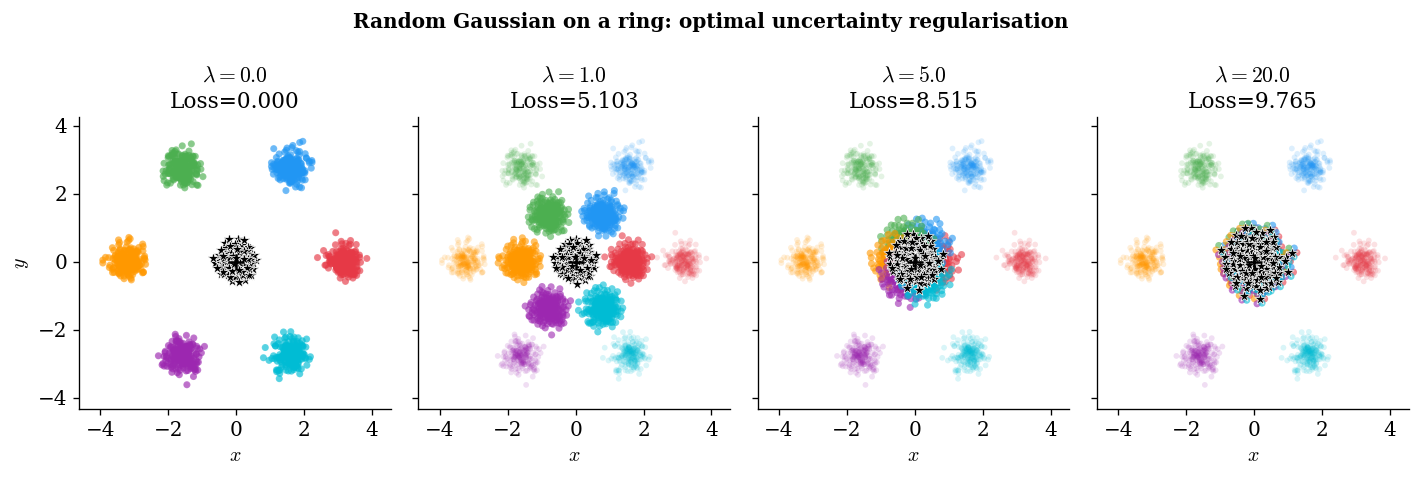

In [7]:
fig, axes = plt.subplots(1, len(LAMBDAS2), figsize=(12, 4), facecolor=BG, sharex=True, sharey=True,
    constrained_layout=True,)
xlim2, ylim2 = get_common_lims(init_ring, targets_ring, pad=0.7)
bary_ring_target = compute_barycenter(targets_ring, n_iter=30)

for ax, lam in zip(axes, LAMBDAS2):
    h = histories_exp2[lam]
    final_particles = h['particles_history'][-1]
    final_bary = h['barycenter_history'][-1]
    
    plot_particles(ax, targets_ring, colors2, alpha=0.15, s=12, zorder=1)
    plot_particles(ax, final_particles, colors2, alpha=0.6, s=18, zorder=2)
    plot_barycenter(ax, final_bary, color='black', s=50)
    
    # Mark the origin
    ax.plot(0, 0, 'k+', markersize=10, markeredgewidth=1.5, zorder=6)
    
    ax.set_xlim(xlim2); ax.set_ylim(ylim2)
    ax.set_aspect('equal')
    ax.set_title(f'$\\lambda = {lam}$\nLoss={h["loss_history"][-1]:.3f}')
    ax.set_xlabel('$x$')
    if ax == axes[0]:
        ax.set_ylabel('$y$')

plt.suptitle(
    'Random Gaussian on a ring: optimal uncertainty regularisation',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig('ring_uncertainty.png', dpi=150, bbox_inches='tight')
plt.savefig('ring_uncertainty.pdf', bbox_inches='tight')
plt.show()

---
# Fidelity-Uncertainty Tradeoff Curve

We now sweep $\lambda$ over a fine grid and plot the **Pareto frontier** of fidelity vs. variance at the final state $M^*_\lambda$. This visualises the fundamental tradeoff:

$$\text{Fidelity}(M^*_\lambda) = \mathbb{E}_\omega[W_2^2(\xi(\omega), M^*_\lambda(\omega))], \quad \text{Var}_W(M^*_\lambda) = \mathbb{E}_\omega[W_2^2(M^*_\lambda(\omega), \bar{M}^*_\lambda)]$$

As $\lambda$ increases, fidelity increases (we move away from $\xi$) and variance decreases (realisations converge). The curve traces the efficient frontier between these two objectives.

In [8]:
lambda_sweep = [0.0, 0.1, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0, 3.0, 5.0, 8.0, 12.0, 20.0]

fidelities_sweep = []
variances_sweep = []

N_STEPS = 20
STEP_SIZE = 0.2

print('Lambda sweep...')
for lam in lambda_sweep:
    h = variance_regularised_flow(
        init_ring, targets_ring, lam=lam,
        n_steps=N_STEPS, step_size=STEP_SIZE,
        barycenter_iters=20, record_every=N_STEPS  # only record final
    )
    fidelities_sweep.append(h['fidelity_history'][-1])
    variances_sweep.append(h['variance_history'][-1])
    print(f'  lambda={lam:.2f}: fidelity={fidelities_sweep[-1]:.4f}, variance={variances_sweep[-1]:.4f}')

print('Done.')

Lambda sweep...
  lambda=0.00: fidelity=0.0014, variance=9.9713
  lambda=0.10: fidelity=0.1049, variance=8.2409
  lambda=0.25: fidelity=0.4466, variance=6.3819
  lambda=0.50: fidelity=1.1868, variance=4.4321
  lambda=0.75: fidelity=1.9328, variance=3.2563
  lambda=1.00: fidelity=2.6114, variance=2.4932
  lambda=1.50: fidelity=3.7332, variance=1.5957
  lambda=2.00: fidelity=4.5929, variance=1.1082
  lambda=3.00: fidelity=5.7946, variance=0.6234
  lambda=5.00: fidelity=7.1400, variance=0.2771
  lambda=8.00: fidelity=8.1189, variance=0.1232
  lambda=12.00: fidelity=8.7551, variance=0.0590
  lambda=20.00: fidelity=9.3216, variance=0.0226
Done.


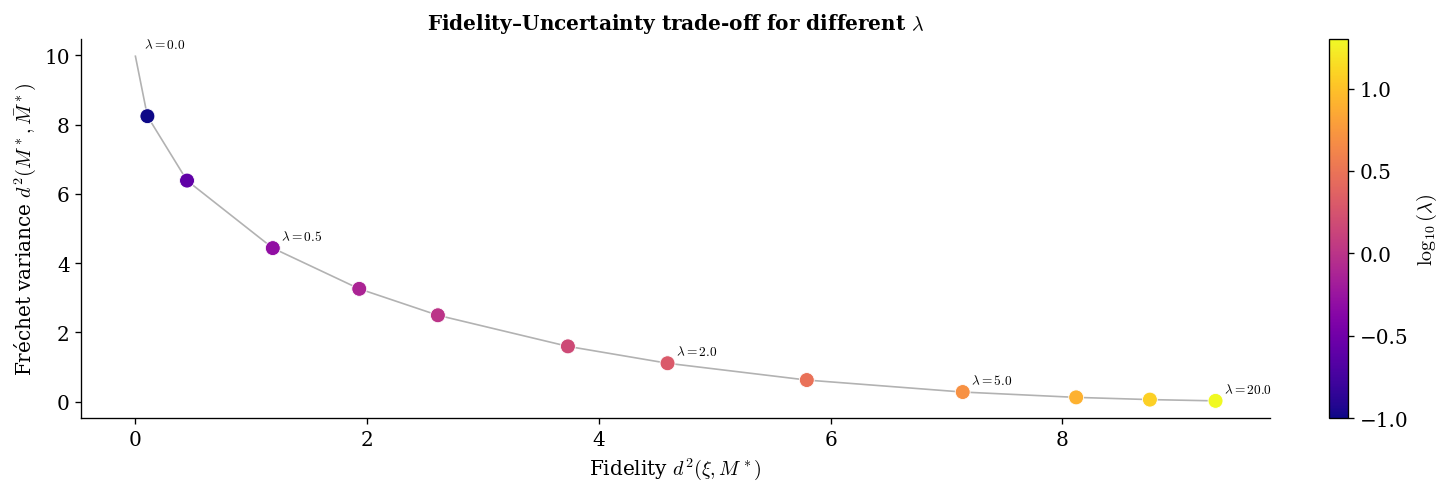

In [9]:
fig, ax = plt.subplots(1, 1, figsize=(12, 4), facecolor=BG, sharex=True, sharey=True,
    constrained_layout=True,)

# Pareto frontier
sc = ax.scatter(fidelities_sweep, variances_sweep,
                c=np.log10([l for l in lambda_sweep]),
                cmap='plasma', s=80, zorder=3,
                edgecolors='white', linewidths=0.5)

ax.plot(fidelities_sweep, variances_sweep, 'k-', alpha=0.3, lw=1)
plt.colorbar(sc, ax=ax, label='$\\log_{10}(\\lambda)$')

for i, lam in enumerate(lambda_sweep):
    if lam in [0.0, 0.5, 2.0, 5.0, 20.0]:
        ax.annotate(f'$\\lambda={lam}$',
                    (fidelities_sweep[i], variances_sweep[i]),
                    textcoords='offset points', xytext=(5, 5), fontsize=8)

ax.set_xlabel('Fidelity $d^2(\\xi, M^*)$')
ax.set_ylabel('Fréchet variance $d^2(M^*, \\bar{M}^*)$')
ax.set_title('Fidelity–Uncertainty trade-off for different $\\lambda$', fontsize=12, fontweight='bold')

plt.savefig('Fidelity_uncertainty_tradeoff.png', dpi=150, bbox_inches='tight')
plt.savefig('Fidelity_uncertainty_tradeoff.pdf', bbox_inches='tight')
plt.show()